# Lesson 02 — NetworkX Foundations

## Learning Goal

Learn practical graph construction in Python by building graphs from real data.

By the end of this lesson, you will:
- Build graphs from CSV (relational) data
- Add and access node and edge attributes
- Filter nodes and edges, create subgraphs
- Export and reload graphs in different formats

**Duration**: 90 minutes

**Estimated time per section**:
- Loading data: 10 minutes
- Building graphs: 20 minutes
- Attributes: 20 minutes
- Filtering & subgraphs: 20 minutes
- Export/import: 15 minutes
- Exercises: 5 minutes

## Setup and Data Loading

Import libraries and load the support ticket dataset.

In [41]:
import sys
from pathlib import Path

# Add src directory to path to import config
project_root = Path(__file__).parent.parent if '__file__' in dir() else Path.cwd().parent
sys.path.insert(0, str(project_root))

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

# Load config or construct path manually
try:
    from src.config import Config
    DATA_DIR = Config.PROJECT_ROOT / 'data' / 'seed' / 'support_escalation'
except ImportError:
    # Fallback: construct path from notebook location
    # Notebooks are at: project_root/notebooks/
    # Data is at: project_root/data/seed/support_escalation/
    notebook_dir = Path.cwd()
    if notebook_dir.name == 'notebooks':
        project_root = notebook_dir.parent
    else:
        project_root = notebook_dir.parent.parent if (notebook_dir.parent.parent / 'data').exists() else notebook_dir
    DATA_DIR = project_root / 'data' / 'seed' / 'support_escalation'

def display_csv_head(df, name, n=5):
    """Display DataFrame info and head."""
    print(f"\n{name}:")
    print(f"  Shape: {df.shape} (rows, columns)")
    print(f"  Columns: {list(df.columns)}")
    print(f"\n  First {n} rows:")
    print(df.head(n).to_string(index=False))

# Load datasets
customers_df = pd.read_csv(DATA_DIR / 'customers.csv')
tickets_df = pd.read_csv(DATA_DIR / 'tickets.csv')
escalations_df = pd.read_csv(DATA_DIR / 'escalations.csv')

print("Data loaded successfully!")
print(f"  Customers: {len(customers_df)} rows")
print(f"  Tickets: {len(tickets_df)} rows")
print(f"  Escalations: {len(escalations_df)} rows")

Data loaded successfully!
  Customers: 20 rows
  Tickets: 50 rows
  Escalations: 19 rows


## 1. Understanding the Dataset

We have a **support ticket system** with three entities:

- **Customers**: Companies using the support system
- **Tickets**: Support requests created by customers
- **Escalations**: Agent-to-agent routing when issues are complex

The relationships form a graph:
- Customers — Tickets: customers create tickets (node-to-node relationship)
- Agents — Agents: escalations create agent-to-agent routes (edges with metadata like escalation level and ticket info)
- Note: This simple lesson graph does not directly connect tickets to agents. Instead, escalation metadata (ticket_id) is stored on agent-agent edges.

In [42]:
# Examine each dataset
display_csv_head(customers_df, "Customers", n=5)
display_csv_head(tickets_df, "Tickets", n=5)
display_csv_head(escalations_df, "Escalations", n=5)


Customers:
  Shape: (20, 4) (rows, columns)
  Columns: ['customer_id', 'name', 'region', 'priority_level']

  First 5 rows:
customer_id                            name  region priority_level
   CUST_001 Rodriguez, Figueroa and Sanchez    West       Critical
   CUST_002                       Doyle Ltd    East           High
   CUST_003   Mcclain, Miller and Henderson Central            Low
   CUST_004                  Davis and Sons    East            Low
   CUST_005     Guzman, Hoffman and Baldwin    East           High

Tickets:
  Shape: (50, 6) (rows, columns)
  Columns: ['ticket_id', 'customer_id', 'status', 'priority', 'created_date', 'resolved_date']

  First 5 rows:
ticket_id customer_id   status priority        created_date       resolved_date
 TKT_0001    CUST_004     Open Critical 2024-01-02 04:42:35 2024-01-20 04:42:35
 TKT_0002    CUST_002 Resolved      Low 2024-01-15 14:45:52 2024-01-24 14:45:52
 TKT_0003    CUST_008  Waiting Critical 2024-01-26 20:41:29 2024-02-07 20:41:2

In [43]:
# Basic statistics
print("\nDataset Statistics:")
print(f"\nCustomers by region:")
print(customers_df['region'].value_counts())
print(f"\nTickets by status:")
print(tickets_df['status'].value_counts())
print(f"\nTickets by priority:")
print(tickets_df['priority'].value_counts())


Dataset Statistics:

Customers by region:
region
East       7
West       5
South      5
Central    3
Name: count, dtype: int64

Tickets by status:
status
Open           16
Resolved       11
Waiting        10
In Progress     7
Closed          6
Name: count, dtype: int64

Tickets by priority:
priority
Medium      31
Low          8
High         7
Critical     4
Name: count, dtype: int64


## 2. Building Graphs from Relational Data

To build a graph from CSV data, we need to:

1. **Identify nodes**: What are the entities? (Customers, Tickets, Agents)
2. **Identify edges**: What are the relationships? (Customer creates Ticket, Agent handles Ticket, Agent escalates to Agent)
3. **Add attributes**: What properties do nodes/edges have? (Customer region/priority, Ticket status/priority, Escalation level)

Let's build this step-by-step.

In [44]:
# Create empty graph
G = nx.Graph()

# Step 1: Add customer nodes
for idx, row in customers_df.iterrows():
    G.add_node(row['customer_id'], node_type='customer', **row.to_dict())

print(f"Step 1: Added {len(customers_df)} customer nodes")
print(f"  Total nodes in graph: {G.number_of_nodes()}")

# Step 2: Add ticket nodes
for idx, row in tickets_df.iterrows():
    G.add_node(row['ticket_id'], node_type='ticket', **row.to_dict())

print(f"\nStep 2: Added {len(tickets_df)} ticket nodes")
print(f"  Total nodes in graph: {G.number_of_nodes()}")

# Step 3: Add edges (customer → ticket)
for idx, row in tickets_df.iterrows():
    customer_id = row['customer_id']
    ticket_id = row['ticket_id']
    G.add_edge(customer_id, ticket_id, edge_type='creates', ticket_priority=row['priority'])

print(f"\nStep 3: Added edges (customer → ticket)")
print(f"  Total edges in graph: {G.number_of_edges()}")

Step 1: Added 20 customer nodes
  Total nodes in graph: 20

Step 2: Added 50 ticket nodes
  Total nodes in graph: 70

Step 3: Added edges (customer → ticket)
  Total edges in graph: 50


In [45]:
# Step 4: Add agent nodes and escalation edges
# Extract all unique agents from escalations
agents = set(escalations_df['from_agent'].unique()) | set(escalations_df['to_agent'].unique())
for agent in agents:
    G.add_node(agent, node_type='agent')

print(f"Step 4a: Added {len(agents)} agent nodes")
print(f"  Total nodes in graph: {G.number_of_nodes()}")

# Step 4b: Aggregate escalation routes and add as edges
# Since nx.Graph() collapses duplicate edges between the same pair of nodes,
# we aggregate multiple escalation events into a single edge with aggregate attributes.
escalation_routes = (
    escalations_df
    .groupby(['from_agent', 'to_agent'])
    .agg(
        escalation_count=('ticket_id', 'count'),
        min_escalation_level=('escalation_level', 'min'),
        max_escalation_level=('escalation_level', 'max'),
        ticket_ids=('ticket_id', lambda x: ','.join(sorted(x)))
    )
    .reset_index()
)

for idx, row in escalation_routes.iterrows():
    from_agent = row['from_agent']
    to_agent = row['to_agent']
    G.add_edge(
        from_agent,
        to_agent,
        edge_type='escalates',
        escalation_count=int(row['escalation_count']),
        min_escalation_level=int(row['min_escalation_level']),
        max_escalation_level=int(row['max_escalation_level']),
        ticket_ids=row['ticket_ids']
    )

print(f"Step 4b: Added escalation edges (agent → agent)")
print(f"  Total edges in graph: {G.number_of_edges()}")

# Calculate unique escalation routes for reporting
unique_escalation_routes = len(escalation_routes)

print(f"\n" + "="*60)
print(f"GRAPH SUMMARY")
print(f"="*60)
print(f"Nodes: {G.number_of_nodes()} ({len(customers_df)} customers + {len(tickets_df)} tickets + {len(agents)} agents)")
print(f"Edges: {G.number_of_edges()} ({len(tickets_df)} customer→ticket + {unique_escalation_routes} unique agent→agent escalation routes)")
print(f"Density: {nx.density(G):.3f}")
print(f"\nNote: Because this lesson uses nx.Graph(), duplicate escalations between")
print(f"the same agent pair collapse into one edge. Edge attributes store aggregate")
print(f"information (escalation_count, min/max level, list of ticket_ids).")

Step 4a: Added 7 agent nodes
  Total nodes in graph: 77
Step 4b: Added escalation edges (agent → agent)
  Total edges in graph: 59

GRAPH SUMMARY
Nodes: 77 (20 customers + 50 tickets + 7 agents)
Edges: 59 (50 customer→ticket + 9 unique agent→agent escalation routes)
Density: 0.020

Note: Because this lesson uses nx.Graph(), duplicate escalations between
the same agent pair collapse into one edge. Edge attributes store aggregate
information (escalation_count, min/max level, list of ticket_ids).


In [46]:
# Sanity Check: Verify graph construction
print("="*60)
print("SANITY CHECK: Graph Construction")
print("="*60)

expected_customer_nodes = len(customers_df)
expected_ticket_nodes = len(tickets_df)
expected_agent_nodes = len(agents)
expected_total_nodes = expected_customer_nodes + expected_ticket_nodes + expected_agent_nodes

expected_customer_ticket_edges = len(tickets_df)
expected_unique_escalation_routes = unique_escalation_routes
expected_total_edges = expected_customer_ticket_edges + expected_unique_escalation_routes

# Assertions
assert G.number_of_nodes() == expected_total_nodes, \
    f"Node count mismatch: {G.number_of_nodes()} != {expected_total_nodes}"
assert G.number_of_edges() == expected_total_edges, \
    f"Edge count mismatch: {G.number_of_edges()} != {expected_total_edges}"

print(f"✓ Node count: {G.number_of_nodes()} = {expected_customer_nodes} + {expected_ticket_nodes} + {expected_agent_nodes}")
print(f"✓ Edge count: {G.number_of_edges()} = {expected_customer_ticket_edges} + {expected_unique_escalation_routes}")
print(f"✓ All checks passed!")

SANITY CHECK: Graph Construction
✓ Node count: 77 = 20 + 50 + 7
✓ Edge count: 59 = 50 + 9
✓ All checks passed!


## 3. Visualizing the Graph

Let's visualize a subset of the graph to understand the structure.

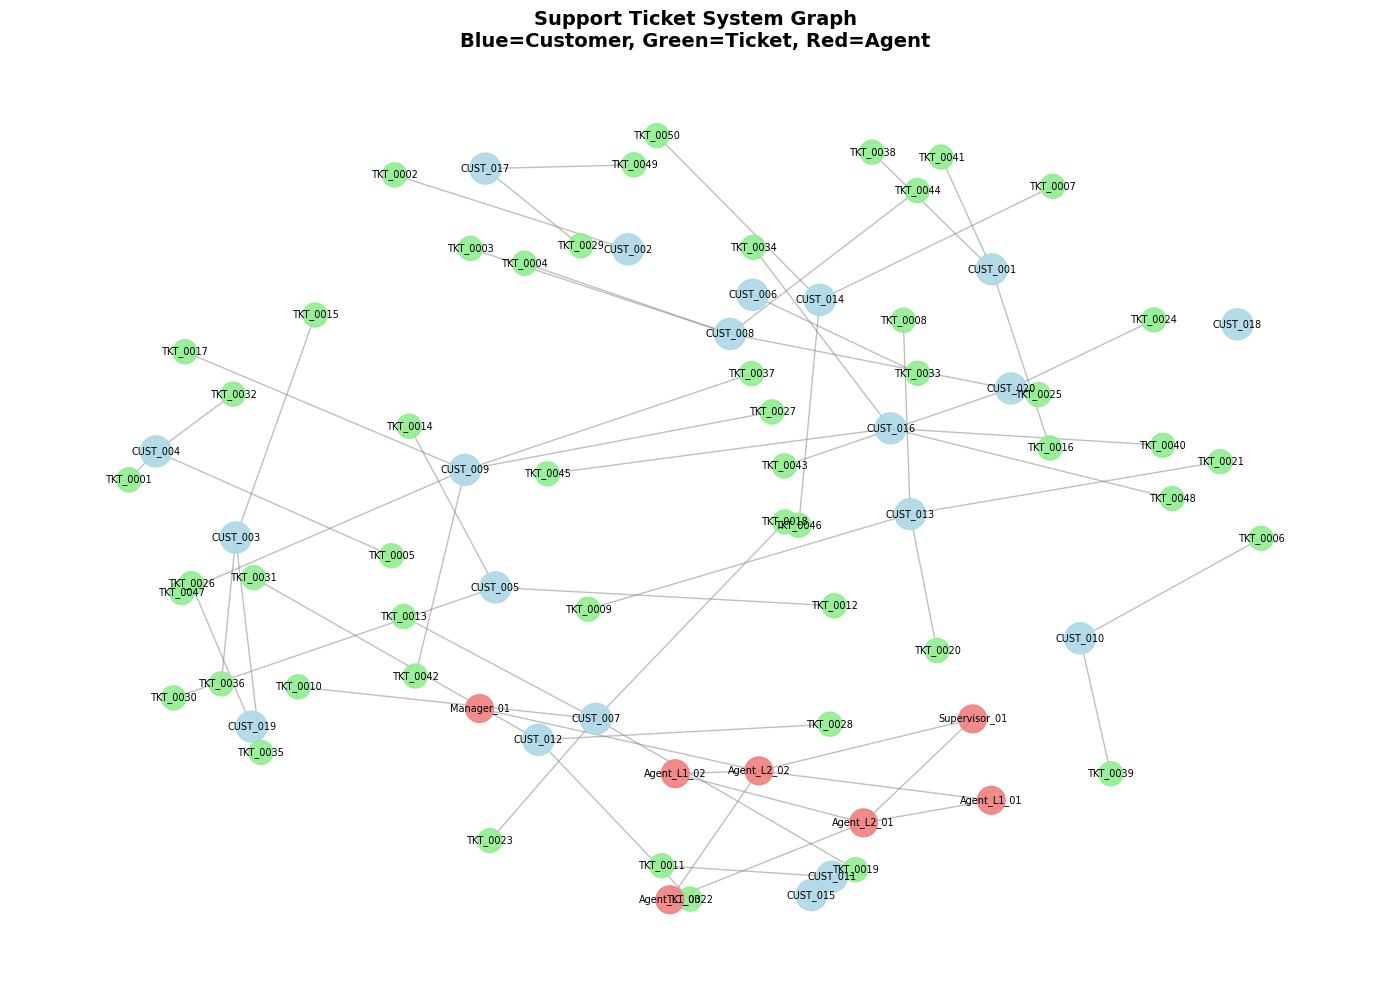

Graph visualization with 77 nodes and 59 edges


In [47]:
# Visualize full graph (small, so should be readable)
fig, ax = plt.subplots(figsize=(14, 10))

# Use spring layout for readability
pos = nx.spring_layout(G, seed=42, k=0.5, iterations=50)

# Color nodes by type
node_colors = []
node_sizes = []
for node in G.nodes():
    node_type = G.nodes[node].get('node_type', 'unknown')
    if node_type == 'customer':
        node_colors.append('lightblue')
        node_sizes.append(500)
    elif node_type == 'ticket':
        node_colors.append('lightgreen')
        node_sizes.append(300)
    else:  # agent
        node_colors.append('lightcoral')
        node_sizes.append(400)

# Draw network
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, ax=ax, alpha=0.9)
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1, ax=ax, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)

ax.set_title("Support Ticket System Graph\nBlue=Customer, Green=Ticket, Red=Agent", fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Graph visualization with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

## 4. Node Attributes

Nodes can store arbitrary attributes (metadata). This is powerful—you can store complex information and query it later.

**Customer nodes** have: `customer_id`, `name`, `region`, `priority_level`  
**Ticket nodes** have: `ticket_id`, `customer_id`, `status`, `priority`, `created_date`, `resolved_date`  
**Agent nodes** have: `node_type` (minimal for now)

In [48]:
# Access node attributes
sample_customer_id = customers_df.iloc[0]['customer_id']
sample_ticket_id = tickets_df.iloc[0]['ticket_id']
sample_agent_id = sorted(agents)[0]

print(f"Sample customer node: {sample_customer_id}")
print(f"  Attributes: {G.nodes[sample_customer_id]}")

print(f"\nSample ticket node: {sample_ticket_id}")
print(f"  Attributes: {G.nodes[sample_ticket_id]}")

print(f"\nSample agent node: {sample_agent_id}")
print(f"  Attributes: {G.nodes[sample_agent_id]}")

Sample customer node: CUST_001
  Attributes: {'node_type': 'customer', 'customer_id': 'CUST_001', 'name': 'Rodriguez, Figueroa and Sanchez', 'region': 'West', 'priority_level': 'Critical'}

Sample ticket node: TKT_0001
  Attributes: {'node_type': 'ticket', 'ticket_id': 'TKT_0001', 'customer_id': 'CUST_004', 'status': 'Open', 'priority': 'Critical', 'created_date': '2024-01-02 04:42:35', 'resolved_date': '2024-01-20 04:42:35'}

Sample agent node: Agent_L1_01
  Attributes: {'node_type': 'agent'}


In [49]:
# Query nodes by attribute
print("Customers in 'West' region:")
west_customers = [node for node in G.nodes() if G.nodes[node].get('region') == 'West']
for cust in west_customers:
    print(f"  {cust}: {G.nodes[cust]['name']} (priority={G.nodes[cust]['priority_level']})")

print(f"\nTickets with 'Critical' priority:")
critical_tickets = [node for node in G.nodes() if G.nodes[node].get('priority') == 'Critical']
for ticket in critical_tickets[:5]:  # Show first 5
    print(f"  {ticket}: status={G.nodes[ticket]['status']}, customer={G.nodes[ticket]['customer_id']}")
if len(critical_tickets) > 5:
    print(f"  ... and {len(critical_tickets) - 5} more")

Customers in 'West' region:
  CUST_001: Rodriguez, Figueroa and Sanchez (priority=Critical)
  CUST_006: Gardner, Robinson and Lawrence (priority=Low)
  CUST_012: Dudley Group (priority=Low)
  CUST_015: Williams and Sons (priority=Low)
  CUST_017: James Group (priority=Medium)

Tickets with 'Critical' priority:
  TKT_0001: status=Open, customer=CUST_004
  TKT_0003: status=Waiting, customer=CUST_008
  TKT_0005: status=Closed, customer=CUST_004
  TKT_0031: status=In Progress, customer=CUST_012


## 5. Edge Attributes

Edges also store attributes. These represent properties of the relationship.

**Customer → Ticket edges** have: `edge_type='creates'`, `ticket_priority`  
**Agent → Agent edges** have: `edge_type='escalates'`, `escalation_level`, `ticket_id`

In [50]:
# Access edge attributes
print("Sample edges and their attributes:\n")

# Get a customer → ticket edge
sample_cust = customers_df.iloc[0]['customer_id']
for neighbor in G.neighbors(sample_cust):
    edge_data = G.get_edge_data(sample_cust, neighbor)
    print(f"Edge: {sample_cust} → {neighbor}")
    print(f"  Attributes: {edge_data}")
    break

print()

# Get an agent → agent edge (if escalations exist)
if len(escalations_df) > 0:
    sample_agent = escalations_df.iloc[0]['from_agent']
    to_agent = escalations_df.iloc[0]['to_agent']
    if G.has_edge(sample_agent, to_agent):
        edge_data = G.get_edge_data(sample_agent, to_agent)
        print(f"Edge: {sample_agent} → {to_agent}")
        print(f"  Attributes: {edge_data}")

Sample edges and their attributes:

Edge: CUST_001 → TKT_0016
  Attributes: {'edge_type': 'creates', 'ticket_priority': 'Medium'}

Edge: Agent_L1_01 → Agent_L2_02
  Attributes: {'edge_type': 'escalates', 'escalation_count': 4, 'min_escalation_level': 1, 'max_escalation_level': 1, 'ticket_ids': 'TKT_0001,TKT_0006,TKT_0016,TKT_0043'}


In [51]:
# Find high-priority tickets
print("High-priority customer→ticket relationships:\n")
high_priority_edges = [
    (u, v, data) for u, v, data in G.edges(data=True)
    if data.get('ticket_priority') == 'Critical' or data.get('ticket_priority') == 'High'
][:5]

for u, v, data in high_priority_edges:
    print(f"  {u} → {v}: priority={data.get('ticket_priority')}")

High-priority customer→ticket relationships:

  CUST_004 → TKT_0001: priority=Critical
  CUST_004 → TKT_0005: priority=Critical
  CUST_007 → TKT_0010: priority=High
  CUST_008 → TKT_0003: priority=Critical
  CUST_008 → TKT_0044: priority=High


## 6. Filtering Nodes

Extract subsets of the graph based on node attributes. This is useful for focusing analysis.

In [52]:
# Filter: Get all customers from a specific region
def get_customers_by_region(G, region):
    """Return list of customer nodes in a specific region."""
    return [node for node in G.nodes() if G.nodes[node].get('region') == region]

# Filter: Get all tickets with a specific status
def get_tickets_by_status(G, status):
    """Return list of ticket nodes with a specific status."""
    return [node for node in G.nodes() if G.nodes[node].get('status') == status]

print("Filtering by customer region:\n")
for region in ['North', 'South', 'East', 'West', 'Central']:
    customers = get_customers_by_region(G, region)
    print(f"  {region}: {len(customers)} customers")

print("\nFiltering by ticket status:\n")
for status in ['Open', 'In Progress', 'Waiting', 'Resolved', 'Closed']:
    tickets = get_tickets_by_status(G, status)
    print(f"  {status}: {len(tickets)} tickets")

Filtering by customer region:

  North: 0 customers
  South: 5 customers
  East: 7 customers
  West: 5 customers
  Central: 3 customers

Filtering by ticket status:

  Open: 16 tickets
  In Progress: 7 tickets
  Waiting: 10 tickets
  Resolved: 11 tickets
  Closed: 6 tickets


## 7. Creating Subgraphs

A **subgraph** is a graph induced by a subset of nodes. Useful for zooming into specific parts of the network.

In [53]:
# Subgraph 1: All critical-priority tickets
critical_tickets = [node for node in G.nodes() if G.nodes[node].get('priority') == 'Critical']
critical_customers = set()
for ticket in critical_tickets:
    for neighbor in G.neighbors(ticket):
        if G.nodes[neighbor].get('node_type') == 'customer':
            critical_customers.add(neighbor)

# Create induced subgraph
nodes_of_interest = critical_tickets + list(critical_customers)
G_critical = G.subgraph(nodes_of_interest).copy()

print(f"Subgraph: Critical-priority tickets and their customers")
print(f"  Nodes: {G_critical.number_of_nodes()} (tickets + customers)")
print(f"  Edges: {G_critical.number_of_edges()}")
print(f"\n  Customer nodes:")
for node in G_critical.nodes():
    if G_critical.nodes[node].get('node_type') == 'customer':
        print(f"    {node}: {G_critical.nodes[node]['name']}")

Subgraph: Critical-priority tickets and their customers
  Nodes: 7 (tickets + customers)
  Edges: 4

  Customer nodes:
    CUST_008: Henderson, Ramirez and Lewis
    CUST_004: Davis and Sons
    CUST_012: Dudley Group


In [54]:
# Subgraph 2: Specific customer and all their tickets
sample_cust = customers_df.iloc[0]['customer_id']
cust_tickets = [neighbor for neighbor in G.neighbors(sample_cust)]
nodes_for_cust_subgraph = [sample_cust] + cust_tickets
G_cust = G.subgraph(nodes_for_cust_subgraph).copy()

print(f"\nSubgraph: Customer {sample_cust} and their tickets")
print(f"  Nodes: {G_cust.number_of_nodes()} (1 customer + {len(cust_tickets)} tickets)")
print(f"  Edges: {G_cust.number_of_edges()}")
print(f"\n  Customer: {G_cust.nodes[sample_cust]['name']}")
print(f"  Tickets:")
for ticket in cust_tickets:
    print(f"    {ticket}: status={G_cust.nodes[ticket]['status']}, priority={G_cust.nodes[ticket]['priority']}")


Subgraph: Customer CUST_001 and their tickets
  Nodes: 4 (1 customer + 3 tickets)
  Edges: 3

  Customer: Rodriguez, Figueroa and Sanchez
  Tickets:
    TKT_0016: status=Closed, priority=Medium
    TKT_0038: status=Waiting, priority=Medium
    TKT_0041: status=Resolved, priority=Medium


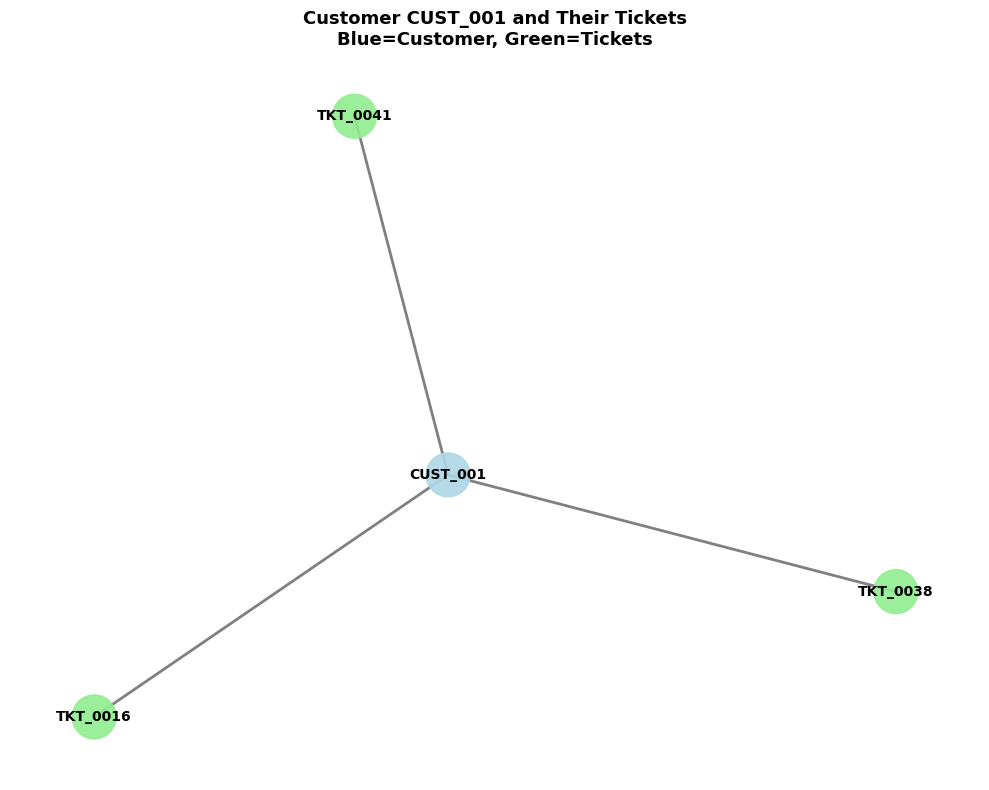

In [55]:
# Visualize customer subgraph
fig, ax = plt.subplots(figsize=(10, 8))

pos = nx.spring_layout(G_cust, seed=42, k=1, iterations=50)

# Color by node type
node_colors = []
for node in G_cust.nodes():
    if G_cust.nodes[node].get('node_type') == 'customer':
        node_colors.append('lightblue')
    else:
        node_colors.append('lightgreen')

nx.draw_networkx_nodes(G_cust, pos, node_color=node_colors, node_size=1000, ax=ax, alpha=0.9)
nx.draw_networkx_edges(G_cust, pos, edge_color='gray', width=2, ax=ax)
nx.draw_networkx_labels(G_cust, pos, font_size=10, ax=ax, font_weight='bold')

ax.set_title(f"Customer {sample_cust} and Their Tickets\nBlue=Customer, Green=Tickets", fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## 8. Graph Queries

Find interesting patterns in the graph using queries.

In [56]:
# Query 1: Which customer has the most tickets?
customer_ticket_counts = {}
for node in G.nodes():
    if G.nodes[node].get('node_type') == 'customer':
        ticket_count = sum(1 for neighbor in G.neighbors(node) if G.nodes[neighbor].get('node_type') == 'ticket')
        customer_ticket_counts[node] = ticket_count

sorted_customers = sorted(customer_ticket_counts.items(), key=lambda x: x[1], reverse=True)
print("Top customers by ticket count:\n")
for cust_id, count in sorted_customers[:5]:
    name = G.nodes[cust_id]['name']
    print(f"  {cust_id} ({name}): {count} tickets")

# Query 2: Which tickets are critical and unresolved?
print("\nCritical and unresolved tickets:\n")
critical_unresolved = [
    node for node in G.nodes()
    if G.nodes[node].get('priority') == 'Critical' and G.nodes[node].get('status') in ['Open', 'In Progress', 'Waiting']
]
print(f"  Found {len(critical_unresolved)} critical unresolved tickets")
for ticket in critical_unresolved[:5]:
    print(f"    {ticket}: status={G.nodes[ticket]['status']}, customer={G.nodes[ticket]['customer_id']}")

Top customers by ticket count:

  CUST_007 (Blake and Sons): 5 tickets
  CUST_009 (Garcia-James): 5 tickets
  CUST_008 (Henderson, Ramirez and Lewis): 4 tickets
  CUST_013 (Arnold Ltd): 4 tickets
  CUST_016 (Galloway-Wyatt): 4 tickets

Critical and unresolved tickets:

  Found 3 critical unresolved tickets
    TKT_0001: status=Open, customer=CUST_004
    TKT_0003: status=Waiting, customer=CUST_008
    TKT_0031: status=In Progress, customer=CUST_012


## 9. Exporting Graphs

Save graphs in different formats for sharing or downstream analysis.

**GraphML**: Preserves all node and edge attributes, human-readable XML. Best for portability with complete metadata.

**Edge list**: Minimal format (just source, target per line). Does not preserve node attributes, isolated nodes, or complex edge data. Good for simple structure sharing.

**Adjacency matrix**: Numeric format, good for algorithms. Does not preserve node/edge metadata.

In [57]:
# Export to GraphML (preserves attributes)
export_dir = Path('data/generated')
export_dir.mkdir(parents=True, exist_ok=True)

# Export full graph
graphml_path = export_dir / 'support_tickets.graphml'
nx.write_graphml(G, graphml_path)
print(f"✓ Exported to GraphML: {graphml_path}")
print(f"  File size: {graphml_path.stat().st_size / 1024:.1f} KB")
print(f"  Preserves: All node attributes, all edge attributes")

# Export as edge list (minimal: just source and target)
edgelist_path = export_dir / 'support_tickets.edgelist'
nx.write_edgelist(G, edgelist_path, data=False)
print(f"\n✓ Exported to edge list: {edgelist_path}")
print(f"  File size: {edgelist_path.stat().st_size / 1024:.1f} KB")
print(f"  Loses: Node attributes, edge attributes, isolated nodes")

# Export as adjacency matrix
import numpy as np
adj_matrix = nx.to_numpy_array(G)
npy_path = export_dir / 'support_tickets_adj_matrix.npy'
np.save(npy_path, adj_matrix)
print(f"\n✓ Exported adjacency matrix: {npy_path}")
print(f"  Shape: {adj_matrix.shape}")
print(f"  Loses: Node/edge attributes, node labels")

✓ Exported to GraphML: data/generated/support_tickets.graphml
  File size: 26.5 KB
  Preserves: All node attributes, all edge attributes

✓ Exported to edge list: data/generated/support_tickets.edgelist
  File size: 1.1 KB
  Loses: Node attributes, edge attributes, isolated nodes

✓ Exported adjacency matrix: data/generated/support_tickets_adj_matrix.npy
  Shape: (77, 77)
  Loses: Node/edge attributes, node labels


## 10. Reloading Graphs

Load exported graphs and verify data integrity.

In [58]:
# Reload GraphML
G_reloaded_graphml = nx.read_graphml(graphml_path)

print("GraphML Round-trip Test:")
print(f"  Original nodes: {G.number_of_nodes()}")
print(f"  Reloaded nodes: {G_reloaded_graphml.number_of_nodes()}")
print(f"  Original edges: {G.number_of_edges()}")
print(f"  Reloaded edges: {G_reloaded_graphml.number_of_edges()}")

# Check if attributes survived
sample_node = list(G_reloaded_graphml.nodes())[0]
print(f"\n  Sample node {sample_node} attributes:")
print(f"    {G_reloaded_graphml.nodes[sample_node]}")
print(f"\n  ✓ Attributes PRESERVED in GraphML")

GraphML Round-trip Test:
  Original nodes: 77
  Reloaded nodes: 77
  Original edges: 59
  Reloaded edges: 59

  Sample node CUST_001 attributes:
    {'node_type': 'customer', 'customer_id': 'CUST_001', 'name': 'Rodriguez, Figueroa and Sanchez', 'region': 'West', 'priority_level': 'Critical'}

  ✓ Attributes PRESERVED in GraphML


In [59]:
# Reload edge list
G_reloaded_edgelist = nx.read_edgelist(edgelist_path)

print("\nEdge List Round-trip Test:")
print(f"  Original nodes: {G.number_of_nodes()}")
print(f"  Reloaded nodes: {G_reloaded_edgelist.number_of_nodes()}")
print(f"  Original edges: {G.number_of_edges()}")
print(f"  Reloaded edges: {G_reloaded_edgelist.number_of_edges()}")

# Check if attributes are gone
sample_node = list(G_reloaded_edgelist.nodes())[0]
print(f"\n  Sample node {sample_node} attributes:")
print(f"    {G_reloaded_edgelist.nodes[sample_node]}")
print(f"\n  ✗ Attributes LOST in edge list (expected - format is minimal)")

# Note about node loss
if G_reloaded_edgelist.number_of_nodes() < G.number_of_nodes():
    print(f"\n  ⚠ WARNING: {G.number_of_nodes() - G_reloaded_edgelist.number_of_nodes()} nodes were lost!")
    print(f"     Edge list only includes nodes that have edges. Isolated nodes are not preserved.")


Edge List Round-trip Test:
  Original nodes: 77
  Reloaded nodes: 75
  Original edges: 59
  Reloaded edges: 59

  Sample node CUST_001 attributes:
    {}

  ✗ Attributes LOST in edge list (expected - format is minimal)

  ⚠ WARNING: 2 nodes were lost!
     Edge list only includes nodes that have edges. Isolated nodes are not preserved.


## 11. Which Format to Use?

| Format | Use When | Attributes | Size | Human-Readable |
|--------|----------|-----------|------|----------------|
| **GraphML** | Need complete graph with all metadata | ✓ Yes | Medium | ✓ XML |
| **Edge list** | Only need structure, sharing simple format | ✗ No | Small | ✓ Text |
| **Adjacency matrix** | Running algorithms (matrices, numpy) | ✗ No | Variable | ✗ Binary |
| **GML** | Compatibility with other tools | ✓ Yes | Medium | ✓ Text |
| **JSON** | Web/Python integration | ✓ Yes | Medium | ✓ JSON |

**Recommendation**: Use **GraphML** for most cases. It preserves attributes and is portable.

## 12. Student Exercises

### Exercise 1: Build a Custom Graph

Create a new ticket for a customer and add it to the graph.

In [60]:
# SOLUTION: Exercise 1

# Create a new ticket
new_ticket_id = 'TKT_NEW_001'
sample_customer = customers_df.iloc[0]['customer_id']

# Add ticket node
G_with_new = G.copy()
G_with_new.add_node(
    new_ticket_id,
    node_type='ticket',
    ticket_id=new_ticket_id,
    customer_id=sample_customer,
    status='Open',
    priority='High',
    created_date='2024-12-15 10:00:00',
    resolved_date=None
)

# Add edge from customer to ticket
G_with_new.add_edge(sample_customer, new_ticket_id, edge_type='creates', ticket_priority='High')

print(f"Added new ticket: {new_ticket_id}")
print(f"  Customer: {sample_customer}")
print(f"  Status: Open")
print(f"  Priority: High")
print(f"\nGraph now has {G_with_new.number_of_nodes()} nodes and {G_with_new.number_of_edges()} edges")
print(f"(Original: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges)")

Added new ticket: TKT_NEW_001
  Customer: CUST_001
  Status: Open
  Priority: High

Graph now has 78 nodes and 60 edges
(Original: 77 nodes, 59 edges)


### Exercise 2: Analyze Subgraph

Create a subgraph of all 'Open' tickets and their customers.

In [61]:
# SOLUTION: Exercise 2

# Find all open tickets
open_tickets = [node for node in G.nodes() if G.nodes[node].get('status') == 'Open']
print(f"Found {len(open_tickets)} open tickets")

# Find customers of open tickets
open_ticket_customers = set()
for ticket in open_tickets:
    for neighbor in G.neighbors(ticket):
        if G.nodes[neighbor].get('node_type') == 'customer':
            open_ticket_customers.add(neighbor)

print(f"These tickets belong to {len(open_ticket_customers)} customers")

# Create subgraph
nodes_for_subgraph = list(open_tickets) + list(open_ticket_customers)
G_open = G.subgraph(nodes_for_subgraph).copy()

print(f"\nSubgraph of open tickets:")
print(f"  Nodes: {G_open.number_of_nodes()}")
print(f"  Edges: {G_open.number_of_edges()}")
print(f"  Node types: {sum(1 for n in G_open.nodes() if G_open.nodes[n].get('node_type') == 'customer')} customers, {len(open_tickets)} tickets")

Found 16 open tickets
These tickets belong to 9 customers

Subgraph of open tickets:
  Nodes: 25
  Edges: 16
  Node types: 9 customers, 16 tickets


### Exercise 3: Export and Verify

Export the graph to GraphML and verify it reloads correctly with all attributes.

In [62]:
# SOLUTION: Exercise 3

# Export a subgraph
test_export_path = Path('data/generated') / 'test_subgraph.graphml'
nx.write_graphml(G_open, test_export_path)
print(f"Exported subgraph to: {test_export_path}")

# Reload it
G_test_reloaded = nx.read_graphml(test_export_path)
print(f"\nReloaded graph:")
print(f"  Nodes: {G_test_reloaded.number_of_nodes()}")
print(f"  Edges: {G_test_reloaded.number_of_edges()}")

# Verify integrity
print(f"\nVerification:")
print(f"  Original subgraph nodes: {G_open.number_of_nodes()}")
print(f"  Reloaded subgraph nodes: {G_test_reloaded.number_of_nodes()}")
print(f"  Match: {G_open.number_of_nodes() == G_test_reloaded.number_of_nodes()}")

# Sample attribute check
sample_node = list(G_test_reloaded.nodes())[0]
print(f"\n  Sample node attributes preserved:")
print(f"    {sample_node}: {G_test_reloaded.nodes[sample_node]}")
print(f"\n✓ Export/import cycle successful!")

Exported subgraph to: data/generated/test_subgraph.graphml

Reloaded graph:
  Nodes: 25
  Edges: 16

Verification:
  Original subgraph nodes: 25
  Reloaded subgraph nodes: 25
  Match: True

  Sample node attributes preserved:
    TKT_0013: {'node_type': 'ticket', 'ticket_id': 'TKT_0013', 'customer_id': 'CUST_007', 'status': 'Open', 'priority': 'Medium', 'created_date': '2024-03-11 18:16:30', 'resolved_date': nan}

✓ Export/import cycle successful!


## 13. Key Takeaways

### Building Graphs from Data

1. **Identify entities and relationships**
   - Entities → nodes
   - Relationships → edges

2. **Add attributes**
   - Nodes store metadata (name, type, properties)
   - Edges store relationship info (weight, type, direction)

3. **Use GraphML for portability**
   - Preserves all attributes
   - XML-based, human-readable
   - Supported by all graph tools

4. **Filter and query before algorithms**
   - Extract subgraphs by condition
   - Zoom into specific parts
   - Find patterns (top nodes, bottlenecks, clusters)

### When to Build Graphs

- **CSV data with relationships** → Build graph
- **Need to find paths or clusters** → Build graph
- **Relationships matter to your analysis** → Build graph
- **Just need row counts or aggregates** → Use table

### Next Steps

**Lesson 03 - Graph Profiling**: Measure graphs systematically—degree distributions, clustering coefficients, connected components.

**Lesson 04 - Centrality Algorithms**: Find the most important nodes using multiple definitions of "importance".

---

**Congratulations!** You can now build graphs from real data and export them for sharing. Next, you'll learn to analyze graph structure deeply.